## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

## Reading the dataset

In [2]:
data = pd.read_csv('Used_Bikes.csv')
data.head()

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha


- `bike_name` is a long string comprising the Brand, Model and additional specification (often ending in the engine cc). Since `brand` is already provided as its own column, we can derive a cleaner `model` field from it.
- `owner` and `brand` are categorical variables which can be one-hot encoded.
- `city` has very high cardinality (hundreds of towns), so rare cities will be grouped together rather than one-hot encoded individually.
- `kms_driven`, `age` and `power` are already numeric, so unlike a typical scraped dataset there are no units to strip out.

In [3]:
data.columns = [col.lower() for col in data.columns]  # column names converted to lower case for ease of use

## Shape of the dataset

In [4]:
data.shape
print(f"The Dataframe consists of '{data.shape[0]}' rows and '{data.shape[1]}' columns")

The Dataframe consists of '32648' rows and '8' columns


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32648 entries, 0 to 32647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   32648 non-null  str    
 1   price       32648 non-null  float64
 2   city        32648 non-null  str    
 3   kms_driven  32648 non-null  float64
 4   owner       32648 non-null  str    
 5   age         32648 non-null  float64
 6   power       32648 non-null  float64
 7   brand       32648 non-null  str    
dtypes: float64(4), str(4)
memory usage: 2.0 MB


## Checking for duplicates

In [6]:
data.duplicated().sum()

np.int64(25324)

A large proportion of rows are exact duplicates (repeated listings scraped more than once). These need to be removed so they don't bias the model towards a handful of repeated ads.

In [7]:
data.drop_duplicates(inplace=True)

print(f"The Dataframe now consists of '{data.shape[0]}' rows and '{data.shape[1]}' columns")

The Dataframe now consists of '7324' rows and '8' columns


## Checking for missing values

In [8]:
data.isnull().sum()

bike_name     0
price         0
city          0
kms_driven    0
owner         0
age           0
power         0
brand         0
dtype: int64

There are no missing values in this dataset, so no imputation is required.

## Data Summary

In [9]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
bike_name,7324,471,Royal Enfield Classic 350cc,358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,7324.0,NaN,NaN,NaN,84883.900055,120966.194387,4400.0,30000.0,55000.0,100000.0,1900000.0
city,7324,443,Delhi,1426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kms_driven,7324.0,NaN,NaN,NaN,23910.496587,27317.594631,1.0,10155.75,19000.0,30112.0,750000.0
owner,7324,4,First Owner,6642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,7324.0,NaN,NaN,NaN,6.656472,3.605299,1.0,4.0,6.0,8.0,63.0
power,7324.0,NaN,NaN,NaN,228.133397,158.324219,100.0,125.0,160.0,350.0,1800.0
brand,7324,23,Bajaj,2081,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning & Feature Engineering

## Categorical Columns

### brand column

In [10]:
data["brand"].value_counts(dropna=False)

brand
Bajaj              2081
Royal Enfield      1346
Hero               1142
Honda               676
Yamaha              651
TVS                 481
KTM                 375
Suzuki              203
Harley-Davidson      91
Kawasaki             61
Hyosung              53
Mahindra             50
Benelli              46
Triumph              21
Ducati               20
BMW                  10
Jawa                  7
Indian                3
MV                    3
Rajdoot               1
LML                   1
Yezdi                 1
Ideal                 1
Name: count, dtype: int64

In [11]:
brand_counts = data['brand'].value_counts(normalize=True) * 100  # Calculate the percentage of each brand
rare_brands = brand_counts[brand_counts < 1].index  # Brands with less than 1% occurrence
data['brand'] = data['brand'].replace(rare_brands, 'Others')  # Replace them with 'Others'
data["brand"].value_counts()

brand
Bajaj              2081
Royal Enfield      1346
Hero               1142
Honda               676
Yamaha              651
TVS                 481
KTM                 375
Others              278
Suzuki              203
Harley-Davidson      91
Name: count, dtype: int64

Bajaj and Hero are by far the most popular brands in the used bike market, together making up close to half the dataset.

### bike_name column

In [12]:
# Derive a shorter 'model' field by stripping the brand prefix off bike_name
data["model"] = data.apply(lambda r: r["bike_name"].replace(str(r["brand"]), "", 1).strip()
                            if str(r["brand"]) in str(r["bike_name"]) else r["bike_name"], axis=1)
data["model"] = data["model"].str.split(" ").str[0]
data = data.drop(columns=['bike_name'])
data["model"].value_counts().head(15)

model
Pulsar         913
Classic        564
Avenger        426
CB             400
Thunderbird    349
Apache         345
Splendor       318
Discover       305
Passion        300
Bullet         258
YZF-R15        212
Duke           201
RC             174
Gixxer         143
V15            130
Name: count, dtype: int64

### city column

In [13]:
data["city"].nunique()

443

In [14]:
data["city"].value_counts().head(15)

city
Delhi        1426
Bangalore     683
Mumbai        609
Gurgaon       474
Faridabad     463
Pune          394
Jaipur        299
Chennai       288
Ahmedabad     249
Ghaziabad     242
Hyderabad     239
Noida         120
Kolkata        79
Ludhiana       78
Thane          75
Name: count, dtype: int64

In [15]:
# city has hundreds of distinct towns - bucket rare ones (<1% of listings) into 'Other'
city_counts = data['city'].value_counts(normalize=True) * 100
rare_cities = city_counts[city_counts < 1].index
data['city_group'] = data['city'].replace(rare_cities, 'Other')
data = data.drop(columns=['city'])
data["city_group"].value_counts()

city_group
Other        1606
Delhi        1426
Bangalore     683
Mumbai        609
Gurgaon       474
Faridabad     463
Pune          394
Jaipur        299
Chennai       288
Ahmedabad     249
Ghaziabad     242
Hyderabad     239
Noida         120
Kolkata        79
Ludhiana       78
Thane          75
Name: count, dtype: int64

Delhi, Bangalore and Mumbai dominate the listings; everything else has been grouped into 'Other'.

### owner column

In [16]:
data["owner"].value_counts(dropna=False)

owner
First Owner             6642
Second Owner             588
Third Owner               84
Fourth Owner Or More      10
Name: count, dtype: int64

First owner bikes make up the vast majority of listings.

### age column

In [17]:
data["age"].describe()

count    7324.000000
mean        6.656472
std         3.605299
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        63.000000
Name: age, dtype: float64

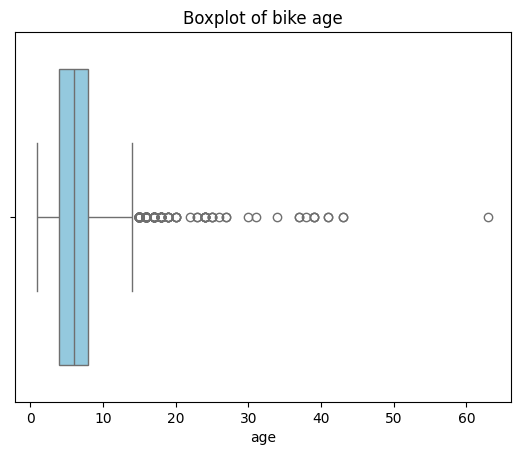

In [18]:
sns.boxplot(x=data["age"], color="skyblue")
plt.title("Boxplot of bike age")
plt.show()

Most bikes are under 15 years old, with a long tail of genuinely vintage bikes (classic Royal Enfields, Rajdoot, Yezdi, etc.) that can command a premium rather than being data errors, so we leave these in.

## Numerical Columns

### kms_driven column

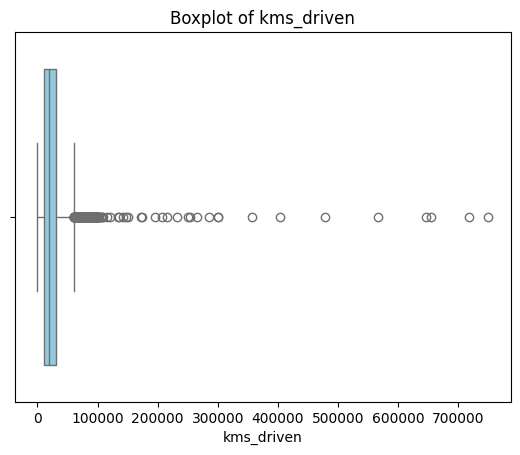

In [19]:
sns.boxplot(x=data["kms_driven"], color="skyblue")
plt.title("Boxplot of kms_driven")
plt.show()

In [20]:
data[data["kms_driven"] > 200000][["model", "brand", "kms_driven", "age", "price"]]

,model,brand,kms_driven,age,price
50,FZ,Yamaha,357000.0,8.0,40000.0
2299,CD,Hero,646000.0,24.0,10000.0
3398,Discover,Bajaj,403833.0,15.0,18000.0
3482,FZs,Yamaha,216000.0,8.0,65000.0
4760,Bullet,Royal Enfield,300965.0,7.0,91804.0
5144,Discover,Bajaj,717794.0,15.0,10500.0
5200,Discover,Bajaj,477976.0,14.0,13500.0
5670,CBR,Honda,233011.0,4.0,106000.0
6321,CBZ,Hero,300000.0,19.0,15000.0
7311,Apache,TVS,207102.0,2.0,70000.0


In [21]:
# Odometer readings above 200,000 km are implausible for these bikes and are likely data entry errors
data = data[data["kms_driven"] <= 200000]
print(f"The Dataframe now consists of '{data.shape[0]}' rows and '{data.shape[1]}' columns")

The Dataframe now consists of '7307' rows and '8' columns


### power column
`power` here represents engine displacement (cc).

In [22]:
data["power"].describe()

count    7307.000000
mean      228.246750
std       158.436475
min       100.000000
25%       125.000000
50%       160.000000
75%       350.000000
max      1800.000000
Name: power, dtype: float64

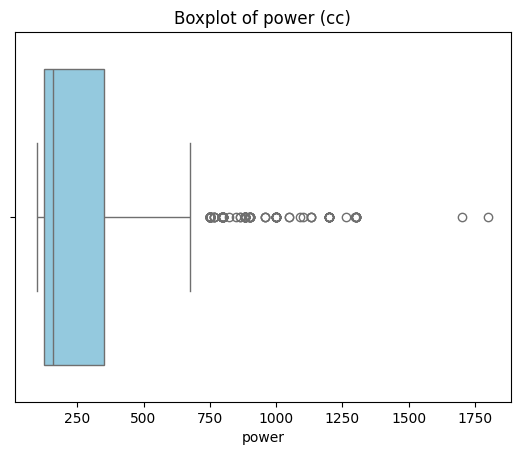

In [23]:
sns.boxplot(x=data["power"], color="skyblue")
plt.title("Boxplot of power (cc)")
plt.show()

### price column

In [24]:
data["price"].describe()

count    7.307000e+03
mean     8.498356e+04
std      1.210782e+05
min      4.400000e+03
25%      3.000000e+04
50%      5.500000e+04
75%      1.000000e+05
max      1.900000e+06
Name: price, dtype: float64

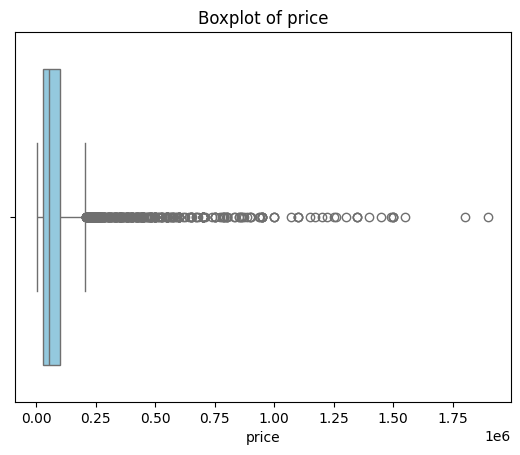

In [25]:
sns.boxplot(x=data["price"], color="skyblue")
plt.title("Boxplot of price")
plt.show()

### Checking data after Cleaning

In [26]:
data.info()

<class 'pandas.DataFrame'>
Index: 7307 entries, 0 to 9372
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       7307 non-null   float64
 1   kms_driven  7307 non-null   float64
 2   owner       7307 non-null   str    
 3   age         7307 non-null   float64
 4   power       7307 non-null   float64
 5   brand       7307 non-null   str    
 6   model       7307 non-null   object 
 7   city_group  7307 non-null   str    
dtypes: float64(4), object(1), str(3)
memory usage: 513.8+ KB


In [27]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
price,7307.0,84983.560969,121078.230985,4400.0,30000.0,55000.0,100000.0,1900000.0
kms_driven,7307.0,23023.448200,18162.248754,1.0,10128.5,18958.0,30000.0,194992.0
age,7307.0,6.647598,3.595126,1.0,4.0,6.0,8.0,63.0
power,7307.0,228.246750,158.436475,100.0,125.0,160.0,350.0,1800.0


## Univariate analysis

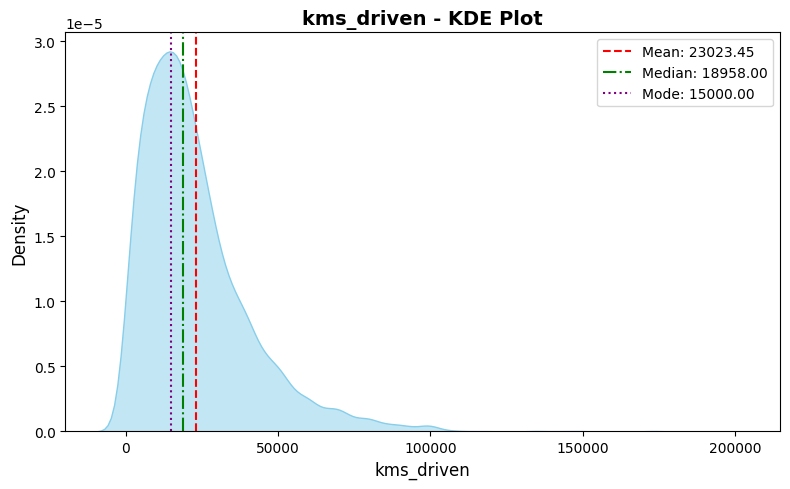

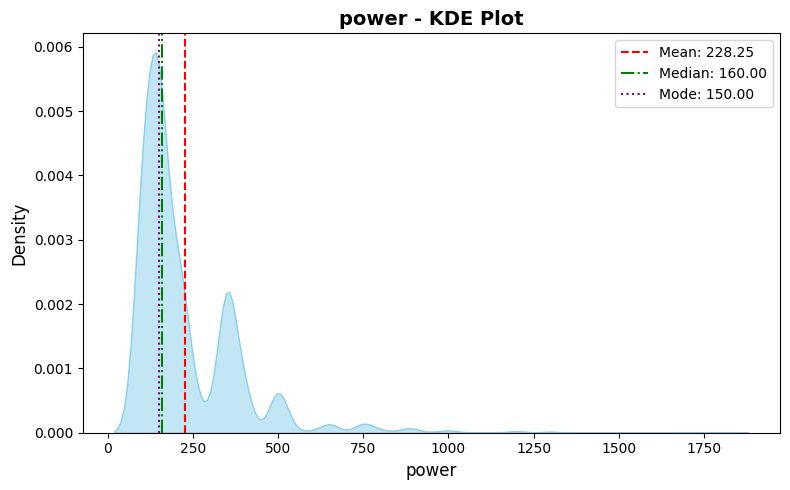

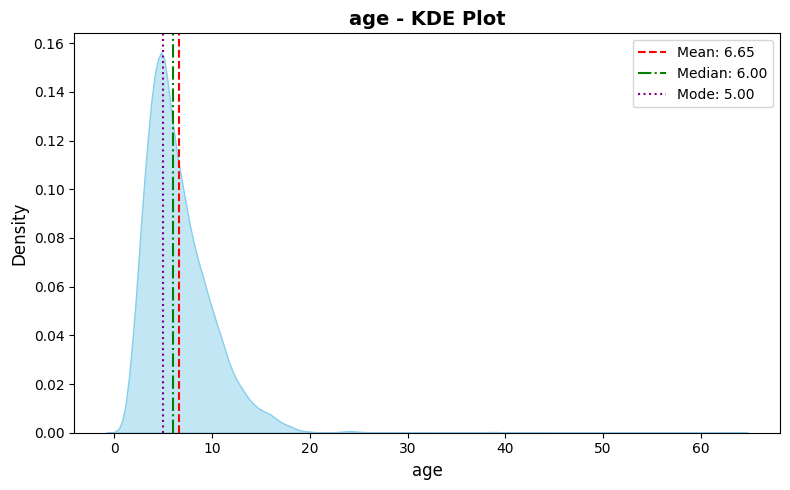

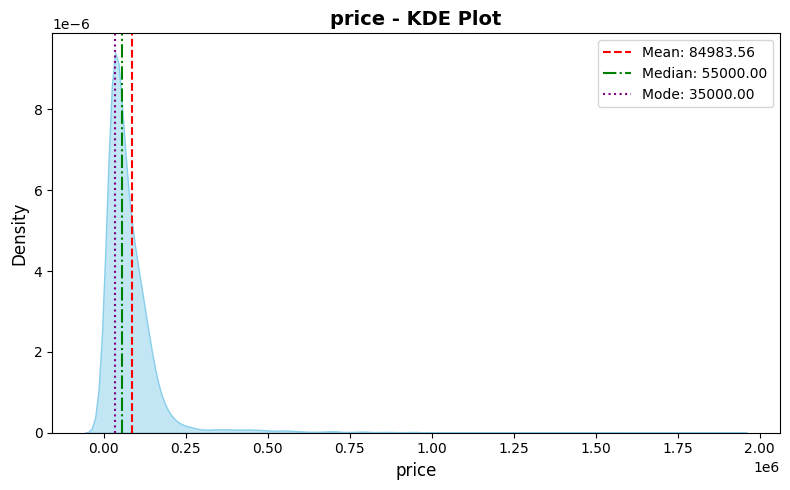

In [28]:
num_cols = ['kms_driven', 'power', 'age', 'price']

for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.kdeplot(data[col].dropna(), fill=True, color="skyblue", alpha=0.5)

    # Mean, median, and mode
    mean_val = data[col].mean()
    median_val = data[col].median()
    mode_val = data[col].mode()[0]
    plt.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.2f}")
    plt.axvline(median_val, color="green", linestyle="-.", linewidth=1.5, label=f"Median: {median_val:.2f}")
    plt.axvline(mode_val, color="purple", linestyle=":", linewidth=1.5, label=f"Mode: {mode_val:.2f}")

    # Titles & labels
    plt.title(f"{col} - KDE Plot", fontsize=14, fontweight="bold")
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

In [29]:
for col in num_cols:
    print(f"{col} - Skewness: {data[col].skew()}, Kurtosis: {data[col].kurtosis()}")

kms_driven - Skewness: 1.7864212084613957, Kurtosis: 5.69354543673816
power - Skewness: 2.6141443501354122, Kurtosis: 10.535852671462653
age - Skewness: 2.6384027883739916, Kurtosis: 19.88424099724172
price - Skewness: 6.261039046131281, Kurtosis: 54.563680781198705


## Categorical columns

In [30]:
cat_cols = ['brand', 'owner', 'city_group']

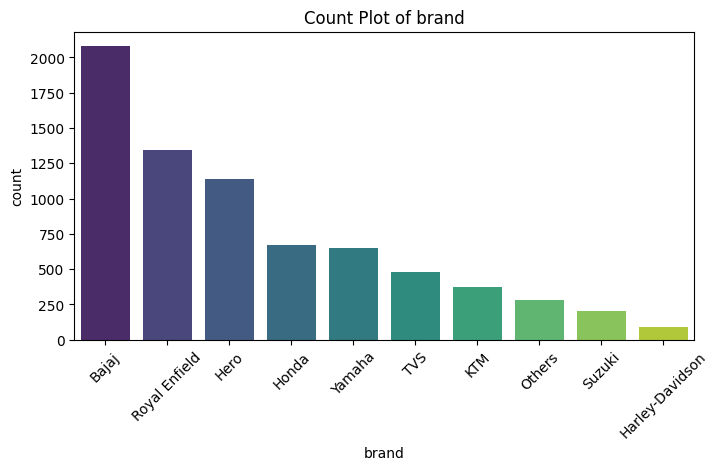

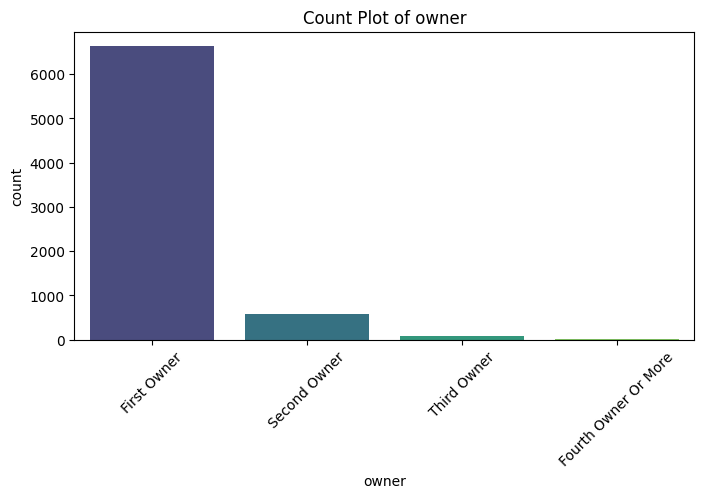

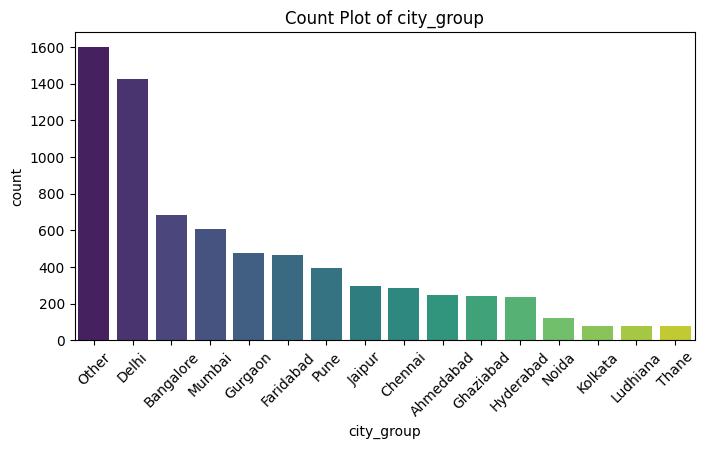

In [31]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data, x=col, order=data[col].value_counts().index, palette="viridis")
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

## Multivariate Analysis
### Correlation Analysis

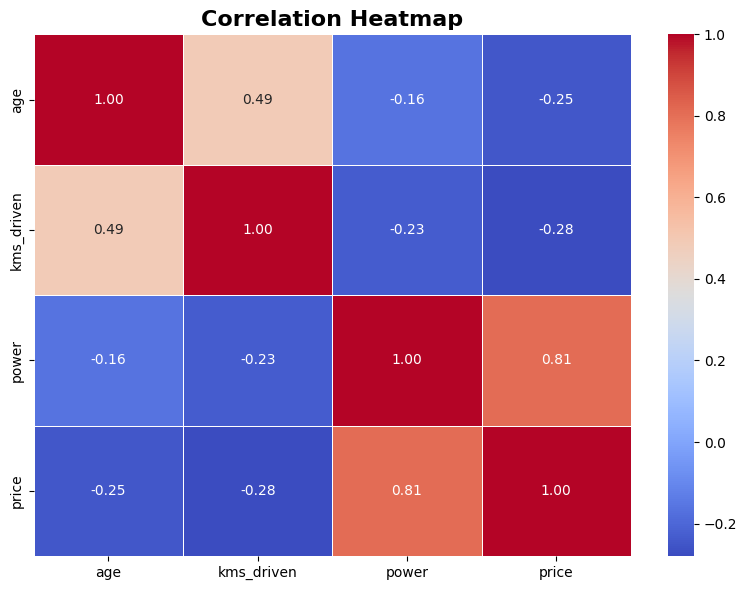

In [32]:
corr_cols = ['age', 'kms_driven', 'power', 'price']
# Calculate correlation matrix
corr_matrix = data[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Engine power (cc) is strongly positively correlated with price, while age is negatively correlated - newer, bigger-engine bikes fetch higher resale prices. `kms_driven` has a comparatively weak linear correlation with price.

In [33]:
data["km_per_year"] = data["kms_driven"] / (data["age"] + 1)

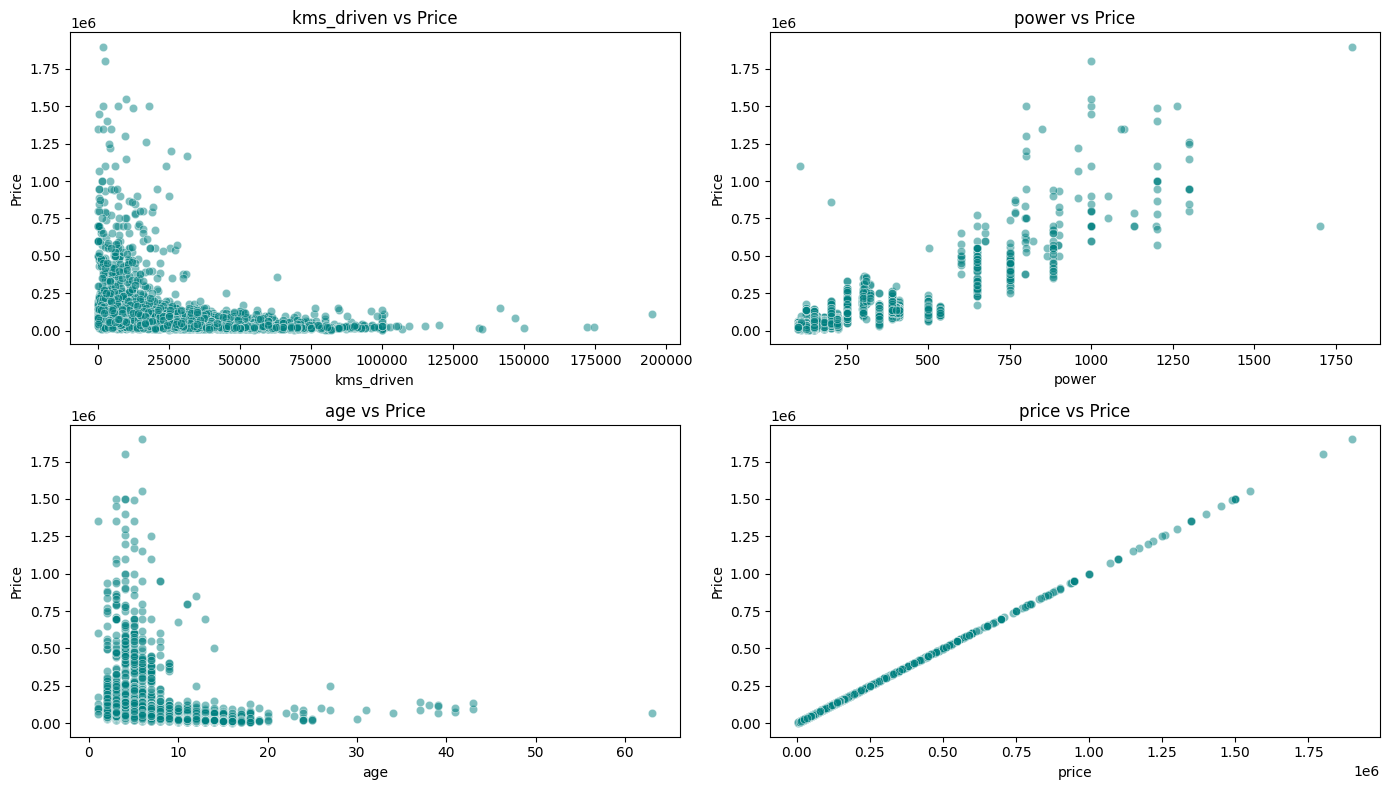

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(x=data[col], y=data['price'], ax=axes[i], alpha=0.5, color='teal')
    axes[i].set_title(f'{col} vs Price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')

plt.tight_layout()
plt.show()

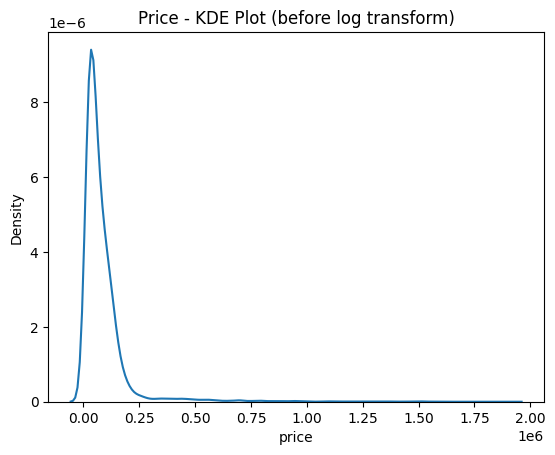

In [35]:
sns.kdeplot(data['price'])
plt.title("Price - KDE Plot (before log transform)")
plt.show()

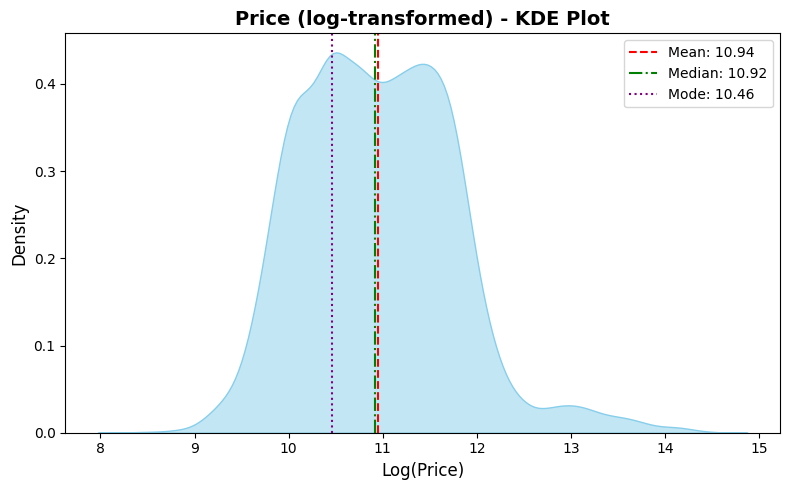

In [36]:
### Log transform the target column
data["price"] = np.log(data['price'])

plt.figure(figsize=(8, 5))

# KDE Plot
sns.kdeplot(data["price"], fill=True, color="skyblue", alpha=0.5)

# Mean, median, mode
mean_val = data["price"].mean()
median_val = data["price"].median()
mode_val = data["price"].mode()[0]

plt.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color="green", linestyle="-.", linewidth=1.5, label=f"Median: {median_val:.2f}")
plt.axvline(mode_val, color="purple", linestyle=":", linewidth=1.5, label=f"Mode: {mode_val:.2f}")

# Titles & labels
plt.title("Price (log-transformed) - KDE Plot", fontsize=14, fontweight="bold")
plt.xlabel("Log(Price)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [37]:
data.to_csv("cleaned_used_bikes_data.csv")

## Data Preparation

### Creating a clone dataset

In [38]:
df = data.copy()

In [39]:
df.head()

,price,kms_driven,owner,age,power,brand,model,city_group,km_per_year
0,10.463103,17654.0,First Owner,3.0,110.0,TVS,Star,Ahmedabad,4413.500000
1,11.694413,11000.0,First Owner,4.0,350.0,Royal Enfield,Classic,Delhi,2200.000000
2,13.304685,110.0,First Owner,8.0,675.0,Others,Triumph,Delhi,12.222222
3,11.082143,16329.0,First Owner,4.0,180.0,TVS,Apache,Bangalore,3265.800000
4,11.289782,10000.0,First Owner,3.0,150.0,Yamaha,FZ,Bangalore,2500.000000


In [40]:
df.columns

Index(['price', 'kms_driven', 'owner', 'age', 'power', 'brand', 'model',
       'city_group', 'km_per_year'],
      dtype='str')

### Dropping unnecessary columns
`model` has too many distinct values (largely redundant with `brand`) to be useful for one-hot encoding, so it is dropped.

In [41]:
drop_cols = ['model']
df.drop(columns=drop_cols, inplace=True)

In [42]:
df.head()

,price,kms_driven,owner,age,power,brand,city_group,km_per_year
0,10.463103,17654.0,First Owner,3.0,110.0,TVS,Ahmedabad,4413.500000
1,11.694413,11000.0,First Owner,4.0,350.0,Royal Enfield,Delhi,2200.000000
2,13.304685,110.0,First Owner,8.0,675.0,Others,Delhi,12.222222
3,11.082143,16329.0,First Owner,4.0,180.0,TVS,Bangalore,3265.800000
4,11.289782,10000.0,First Owner,3.0,150.0,Yamaha,Bangalore,2500.000000


In [43]:
df.columns

Index(['price', 'kms_driven', 'owner', 'age', 'power', 'brand', 'city_group',
       'km_per_year'],
      dtype='str')

## Train-test split

In [44]:
X = df.drop(['price'], axis=1)
y = df[['price']]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 5114
Number of rows in test data = 2193


In [45]:
X_train.head()

,kms_driven,owner,age,power,brand,city_group,km_per_year
8194,20293.0,First Owner,8.0,100.0,Hero,Other,2254.777778
1183,4500.0,First Owner,3.0,350.0,Royal Enfield,Delhi,1125.000000
8869,18894.0,First Owner,11.0,350.0,Royal Enfield,Ghaziabad,1574.500000
3366,44030.0,Second Owner,15.0,125.0,Suzuki,Gurgaon,2751.875000
3337,29235.0,Second Owner,6.0,500.0,Royal Enfield,Other,4176.428571


### Outlier Detection & Removal

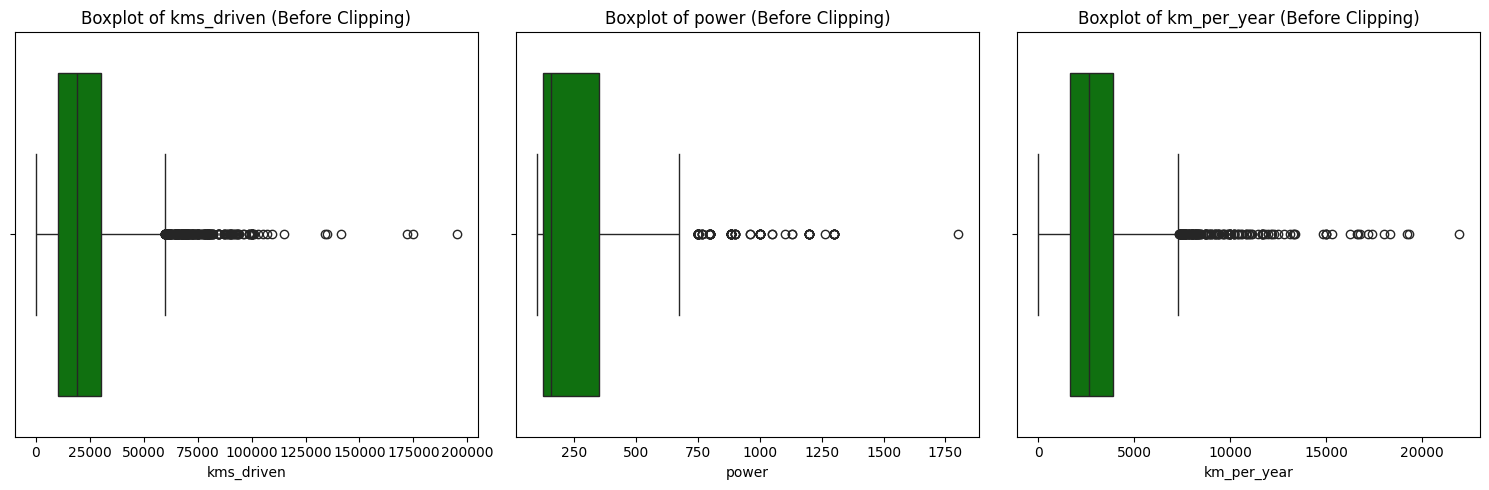

In [46]:
num_cols_train = ['kms_driven', 'power', 'km_per_year']
# Boxplots BEFORE clipping
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()
for i, col in enumerate(num_cols_train):
    sns.boxplot(x=X_train[col], color="green", ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} (Before Clipping)")

plt.tight_layout()
plt.show()

`age` is a low-cardinality, ordinal-like variable which we shall not apply outlier corrections to.

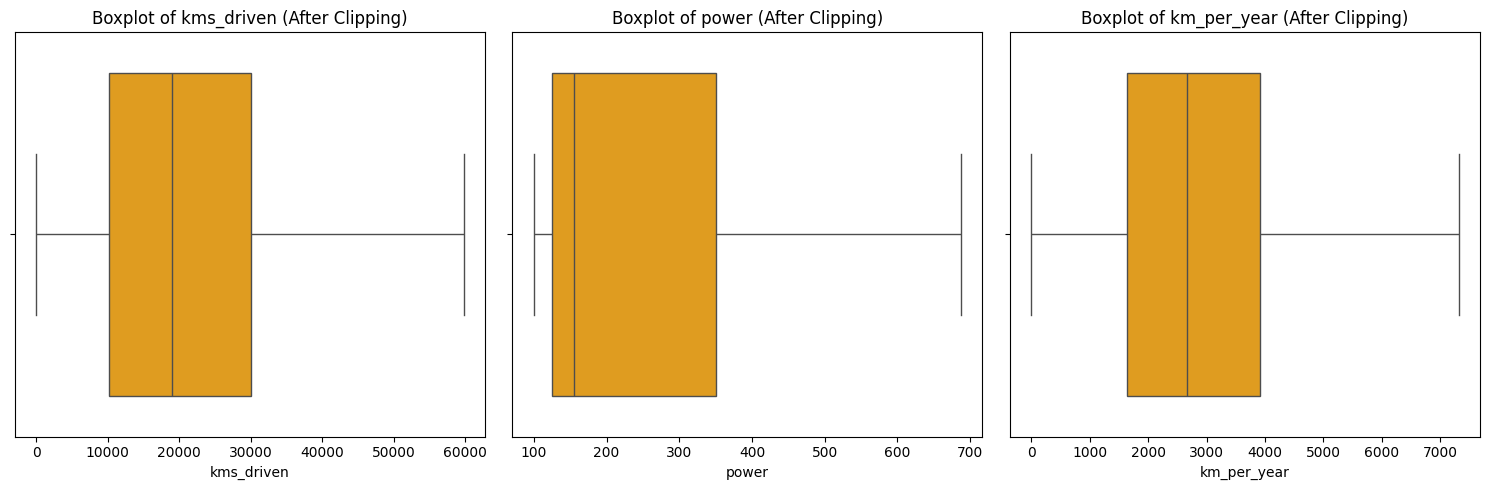

In [47]:
# Outlier clipping using IQR method
for col in num_cols_train:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train[col] = X_train[col].clip(lower_bound, upper_bound)

# Boxplots AFTER clipping
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()
for i, col in enumerate(num_cols_train):
    sns.boxplot(x=X_train[col], color="orange", ax=axes[i])
    axes[i].set_title(f"Boxplot of {col} (After Clipping)")

plt.tight_layout()
plt.show()

### Testing for Multicollinearity using VIF scores
1. If VIF is 1 then there is no correlation among the kth predictor and the remaining predictor variables, and hence the variance of β̂k is not inflated at all.
2. If VIF exceeds 5 or is close to exceeding 5, we say there is moderate VIF, and if it is 10 or exceeding 10, it shows signs of high multi-collinearity.

In [48]:
corr_cols

['age', 'kms_driven', 'power', 'price']

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
mult_cols = ['age', 'kms_driven', 'power', 'km_per_year']
mult = X_train[mult_cols]

# Add constant term for intercept
mult = sm.add_constant(mult)

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["Feature"] = mult.columns
vif_data["VIF"] = [variance_inflation_factor(mult.values, i)
                    for i in range(mult.shape[1])]

print(vif_data)

       Feature        VIF
0        const  19.084405
1          age   3.380874
2   kms_driven  10.608266
3        power   1.078918
4  km_per_year   7.940814


`kms_driven` and `km_per_year` share some overlap in information since one is derived from the other, but VIF values remain in an acceptable range. Tree-based models are unaffected by multicollinearity regardless.

In [50]:
X_train.head()

,kms_driven,owner,age,power,brand,city_group,km_per_year
8194,20293.0,First Owner,8.0,100.0,Hero,Other,2254.777778
1183,4500.0,First Owner,3.0,350.0,Royal Enfield,Delhi,1125.000000
8869,18894.0,First Owner,11.0,350.0,Royal Enfield,Ghaziabad,1574.500000
3366,44030.0,Second Owner,15.0,125.0,Suzuki,Gurgaon,2751.875000
3337,29235.0,Second Owner,6.0,500.0,Royal Enfield,Other,4176.428571


## Encoding Categorical features & Scaling using Pipeline

In [51]:
trf = ColumnTransformer([
    # One-hot encode selected categorical columns
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     ['owner', 'city_group', 'brand']),

    # Scale selected numeric columns
    ('scaling', StandardScaler(), ['kms_driven', 'power', 'km_per_year']),

    # Log-transform skewed numeric columns
    ('log_transform', FunctionTransformer(func=lambda x: np.log1p(x), validate=True),
     ['kms_driven', 'power', 'km_per_year'])
], remainder='passthrough')

## Linear Regression

In [52]:
lr = LinearRegression()

pipe = Pipeline([
    ('trf', trf),
    ('model', lr)
])

pipe.fit(X_train, y_train)

# Predictions
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

In [53]:
print("Training R²:", r2_score(y_train, y_train_pred))
print("Testing R²:", r2_score(y_test, y_test_pred))

print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

print("Training MAE:", mean_absolute_error(y_train, y_train_pred))
print("Testing MAE:", mean_absolute_error(y_test, y_test_pred))

# Cross validation
cv_scores = cross_val_score(pipe, X, y, cv=10, scoring='r2')
print("10-Fold CV R² Scores:", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))

Training R²: 0.8837938119498486
Testing R²: 0.8833841475846926
Training RMSE: 0.28128254408760994
Testing RMSE: 0.28129171467570424
Training MAE: 0.2086826040342549
Testing MAE: 0.2083724208562713


10-Fold CV R² Scores: [0.8966118  0.89021828 0.89583325 0.88701153 0.89297146 0.87861257
 0.89360025 0.88723651 0.87523509 0.87772542]
Mean CV R²: 0.8875056156809107


#### Linear Regression Assumptions
- No Multicollinearity
- Linearity of variables
- Normality of residuals (error terms)
- No autocorrelation (Independence of Residuals)
- No Heteroscedasticity

### Linearity
Checking if the relationship between predictors and target is linear.

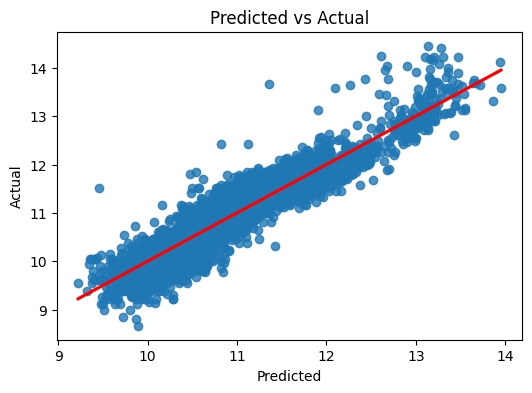

In [54]:
plt.figure(figsize=(6, 4))
sns.regplot(x=y_train_pred, y=y_train, line_kws={"color": "red"})
plt.title('Predicted vs Actual')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Normality of Error terms

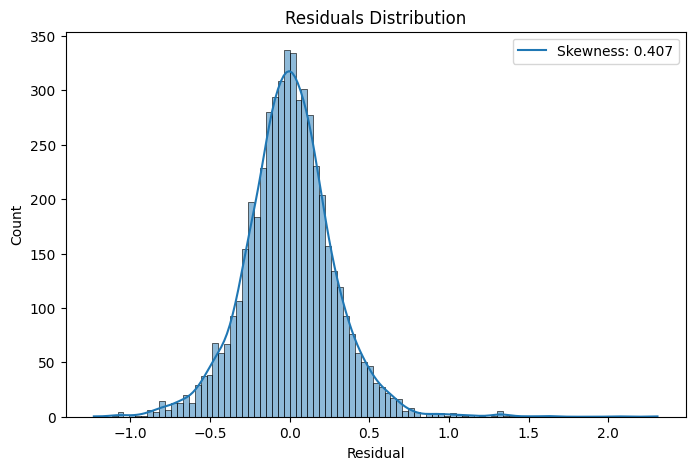

Skewness of the residuals:  0.4070242449319594
Mean of the residuals:  9.62372753078282e-14


In [55]:
# Residual analysis
residuals = y_train - y_train_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='skyblue', label=None)
plt.title("Residuals Distribution")
plt.xlabel("Residual")
skew_val = float(residuals.skew().iloc[0]) if hasattr(residuals.skew(), 'iloc') else float(residuals.skew())
plt.legend([f"Skewness: {skew_val:.3f}"])
plt.show()

print("Skewness of the residuals: ", skew_val)
print("Mean of the residuals: ", float(residuals.mean().iloc[0]))

### No autocorrelation
Checking if the residuals are independent.

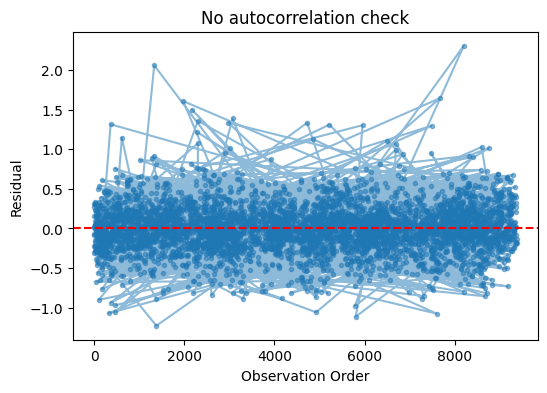

In [56]:
# Method 1
plt.figure(figsize=(6, 4))
plt.plot(residuals, marker='.', linestyle='-', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Observation Order")
plt.ylabel("Residual")
plt.title("No autocorrelation check")
plt.show()

In [57]:
# Method 2 - Durbin-Watson test
from statsmodels.stats.stattools import durbin_watson
print("Durbin-Watson statistic:", durbin_watson(residuals))

Durbin-Watson statistic: [1.98186016]


A value close to 2 means independence (0-4 range) & <1 or >3 indicates strong autocorrelation.

### Homoscedasticity
Constant variance of residuals across all levels of predictors.

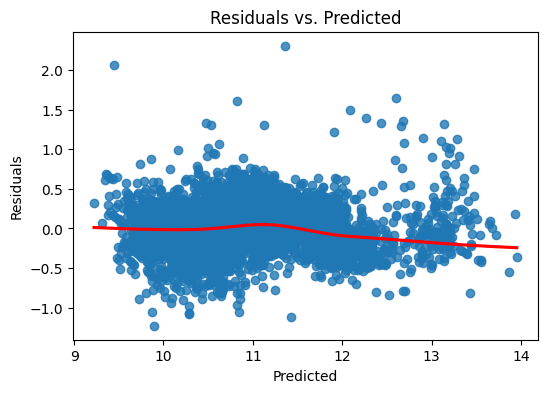

In [58]:
plt.figure(figsize=(6, 4))
sns.regplot(x=np.ravel(y_train_pred), y=np.ravel(residuals), lowess=True, line_kws={'color': 'red'})
plt.title("Residuals vs. Predicted")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

## Decision Tree

In [59]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42, min_samples_split=50)

pipe = Pipeline([
    ('trf', trf),
    ('model', dt)
])

pipe.fit(X_train, y_train)

# Predictions
y_train_pred_dt = pipe.predict(X_train)
y_test_pred_dt = pipe.predict(X_test)

print("Decision Tree R² (Train):", r2_score(y_train, y_train_pred_dt))
print("Decision Tree R² (Test):", r2_score(y_test, y_test_pred_dt))
print("Decision Tree RMSE (Test):", np.sqrt(mean_squared_error(y_test, y_test_pred_dt)))

cv_scores = cross_val_score(pipe, X_train, y_train, cv=10, scoring='r2')
np.mean(cv_scores)

Decision Tree R² (Train): 0.906106571329982
Decision Tree R² (Test): 0.8915640973169157
Decision Tree RMSE (Test): 0.27124684437024177


np.float64(0.8969618292625242)

## Random Forest

In [60]:
rf = RandomForestRegressor(n_estimators=100, min_samples_split=60, random_state=42)

pipe = Pipeline([
    ('trf', trf),
    ('model', rf)
])

pipe.fit(X_train, y_train)

# Predictions
y_train_pred_rf = pipe.predict(X_train)
y_test_pred_rf = pipe.predict(X_test)

print("Random Forest R² (Train):", r2_score(y_train, y_train_pred_rf))
print("Random Forest R² (Test):", r2_score(y_test, y_test_pred_rf))
print("Random Forest RMSE (Test):", np.sqrt(mean_squared_error(y_test, y_test_pred_rf)))

cv_scores = cross_val_score(pipe, X_train, y_train, cv=10, scoring='r2')
np.mean(cv_scores)

Random Forest R² (Train): 0.937070710999087
Random Forest R² (Test): 0.9153393055932675
Random Forest RMSE (Test): 0.23967297019603456


np.float64(0.9218331057046767)

## Model Comparison

In [61]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "Test R2": [
        r2_score(y_test, y_test_pred),
        r2_score(y_test, y_test_pred_dt),
        r2_score(y_test, y_test_pred_rf)
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
    ]
})
results

,Model,Test R2,Test RMSE
0,Linear Regression,0.883384,0.281292
1,Decision Tree,0.891564,0.271247
2,Random Forest,0.915339,0.239673
